### **Credit Card Fraud Detection using Data Science and Machine Learning algorithms**

### **Problem 1: Business Understanding**

In this digital era, monetary transactions are accelerating rapidly towards a cashless system along with which the risk of fraudulent transactions is also increasing.

Credit card fraud is the most common type of identity theft causing nightmare and distress to victims (customers) and businesses who have to compensate for the loss in addition to reputational loss for repeat offences.

Timely intervention on fraud alerts and customer reach is imperative for smooth running of business and retaining customer trust and loyalty to the financial institutions.

The model can serve as a real-world application of imbalanced classification and cost sensitive Machine Learning approaches.

In this exercice , we would build various Predictive machine learning models that can learn from preceding data and estimate the probability of a fraudulent credit card transaction.

The real world implementaiton entails monitoring the activities of
populations of users in order to estimate, perceive or avoid
objectionable behaviour, which consist of fraud, intrusion, and
defaulting.

**Problem Statement**

**The fundamental question we would try to address is** - In all of the classification machine learning algorithms available to us, which one would provide the best performance in detecting close to 100% of fradulent credit card transactions to uphold customer trust and reputation of the financial institiution.


**Real world demonstration of Fraud identification in banking and financial institution.**

### **Problem 2: Data Understanding**

Verified data source from the openml org-
https://api.openml.org/data/download/22121069/dataset
Datasets would be the historical transactions carried out against customers’ accounts . The target variable would be “class” , a binary variable representing fraud or otherwise.

The dataset (from OpenML) contains anonymized features (V1–V28) obtained via PCA transformation, along with

**time** - The time column represents the number of seconds elapsed since the very first transaction in the dataset. To convert this into a more readable 'time of day' format,we will generate a new column by assuming a reference start date (e.g., January 1, 2013, given this was 2013 EU Dataset ) at midnight and adding the elapsed seconds to it. This will allow us to see the transactions mapped to a 24-hour cycle.

**Amount - transaction amount**

**Class** - target variable identifying fraud (1) vs non-fraud transactions(otherwise- 0)

In a real-world scenario, additional features such as transaction location, device type, and login patterns would be useful but are not available due to privacy constraints. They are anonymized through PCA transformations to protect PII .

Even if Data exploration and interpretability and EDA would be limited in scope , the primary operating algorithms, evaluation metrics and predictive analysis does not change. Additionally , we would do multiple plots to understand relationsips between the features.

[Note]- The dataset is in arff format , hence we would use the scipy.io.arff library to read the file and convert into standard csv for ease.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.io import arff

# Import SMOTE library , the standard sklearn pipeline cannot be used here
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from datetime import datetime
from timeit import default_timer as timer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,MinMaxScaler
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

In [2]:
# Connect to google drive to load the full campaign file
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Open the ARFF file
with open("/content/drive/MyDrive/UCbDatasets/creditCardFraudDataset.csv", 'r') as f:

    # Load data and metadata from the ARFF file
    # arff.loadarff handles the ARFF structure (attributes, data section, etc.)
    data, meta = arff.loadarff(f)

# Convert the loaded data (which is a NumPy record array) into a pandas DataFrame
df = pd.DataFrame(data)

# arff.loadarff often returns string columns as byte strings, so decode them
for col in df.select_dtypes(['object']).columns:
    df[col] = df[col].str.decode('utf-8')
df.head(2)

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,123113.0,-4.168525,-4.164323,1.911850,1.130443,4.152041,-2.125948,-1.803619,0.675859,0.308972,...,-0.058678,-1.673241,0.937707,-0.616568,0.780497,-1.055841,-0.154194,0.146745,157.37,otherwise
1,67116.0,-0.241374,-0.043836,1.545847,-0.950404,-0.819948,0.847419,-0.786322,-1.420254,1.645278,...,1.222000,-1.007936,-0.415337,-0.336823,1.033332,0.848539,0.117121,0.092623,96.35,otherwise


In [4]:
# map class variable values otherwise to 0 and fraud to 1
df['class_bool'] = df['class'].map({'otherwise': 0, 'fraud': 1})
df["class_bool"].value_counts()
df.tail(2)

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v22,v23,v24,v25,v26,v27,v28,amount,class,class_bool
28478,132815.0,2.123341,-0.257764,-1.466731,-0.714225,0.026685,-1.049025,0.096077,-0.281468,0.837886,...,-0.838143,0.384608,0.675921,-0.370399,0.512908,-0.109321,-0.061377,4.0,otherwise,0
28479,167387.0,-0.524912,0.420718,-0.026141,0.914060,0.137137,1.011259,0.566047,0.209554,-0.551074,...,0.362233,0.155940,-1.394099,-0.562720,0.665305,-0.124429,-0.190347,139.9,otherwise,0


In [5]:
df.to_csv('creditCardFraudDataset_processed.csv', index=False)
print('DataFrame saved to creditCardFraudDataset_processed.csv')

DataFrame saved to creditCardFraudDataset_processed.csv


### **Exploratory Data Analysis**

Inside this dataset, there are 31 columns out of which 28 are
named as v1-v28 to protect sensitive data.

The other columns represent Time, Amount and Class. Time
shows the time gap between the first transaction and the
following one. Amount is the amount of money transacted.

Class 0 represents a valid transaction and 1 represents a
fraudulent one.

We would plot different graphs to check for inconsistencies in the
dataset and to visually comprehend it:

**Data Cleaning**

In [6]:
# Remove duplicates
df.isnull().sum()# no null  - all 0s
df = df[~df.duplicated()]
df.shape

(28470, 32)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28470 entries, 0 to 28479
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        28470 non-null  float64
 1   v1          28470 non-null  float64
 2   v2          28470 non-null  float64
 3   v3          28470 non-null  float64
 4   v4          28470 non-null  float64
 5   v5          28470 non-null  float64
 6   v6          28470 non-null  float64
 7   v7          28470 non-null  float64
 8   v8          28470 non-null  float64
 9   v9          28470 non-null  float64
 10  v10         28470 non-null  float64
 11  v11         28470 non-null  float64
 12  v12         28470 non-null  float64
 13  v13         28470 non-null  float64
 14  v14         28470 non-null  float64
 15  v15         28470 non-null  float64
 16  v16         28470 non-null  float64
 17  v17         28470 non-null  float64
 18  v18         28470 non-null  float64
 19  v19         28470 non-null  fl

In [8]:
df.describe()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class_bool
count,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,...,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000,28470.000000
mean,94911.677450,0.005833,0.007715,-0.006877,0.009960,0.011365,-0.005290,-0.009413,0.004362,0.007902,...,-0.006348,0.001053,0.001631,-0.003505,-0.007887,0.002628,0.001010,0.000777,86.780619,0.001721
std,47460.069409,1.929114,1.605584,1.511014,1.412434,1.362333,1.316835,1.209920,1.166300,1.105437,...,0.700052,0.721305,0.613606,0.607352,0.521998,0.484636,0.403058,0.307466,225.645074,0.041451
min,0.000000,-33.404082,-38.436817,-30.558697,-5.175917,-27.737487,-20.367836,-43.557242,-41.044261,-13.320155,...,-22.797604,-5.435919,-30.269720,-2.836627,-6.429334,-1.581931,-9.543518,-8.307955,0.000000,0.000000
25%,54487.750000,-0.913603,-0.606529,-0.899083,-0.833708,-0.688307,-0.765537,-0.553344,-0.206693,-0.635535,...,-0.228143,-0.549820,-0.162367,-0.356026,-0.321485,-0.327945,-0.070769,-0.052456,5.632500,0.000000
50%,84806.500000,0.023534,0.070467,0.171742,-0.008973,-0.050526,-0.271454,0.042776,0.022550,-0.047462,...,-0.027992,0.007544,-0.009011,0.039837,0.013150,-0.047003,0.001466,0.011424,22.000000,0.000000
75%,139200.500000,1.315381,0.809012,1.014876,0.748502,0.625443,0.404884,0.579911,0.328417,0.599861,...,0.184364,0.525617,0.150717,0.436883,0.339626,0.245925,0.091293,0.078496,76.067500,0.000000
max,172768.000000,2.420346,22.057729,3.893024,12.699542,29.162172,16.410638,21.444508,19.587773,10.370658,...,16.859008,8.316275,17.751731,4.016342,5.852484,3.517346,9.879903,15.870474,8360.000000,1.000000


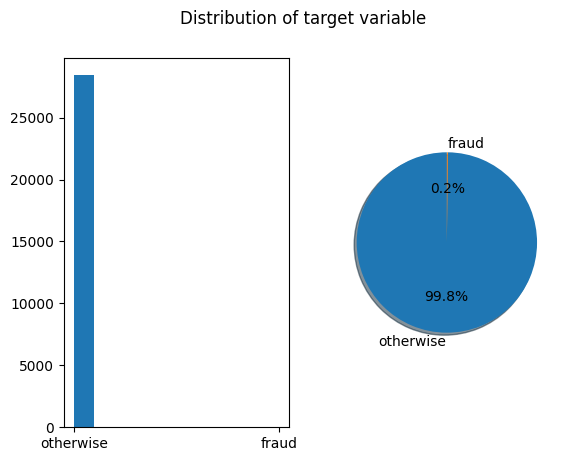

In [9]:
# Plot histogram of target variable y and also the  sliced pie chart and use orange color
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable')
ax1.hist(df['class'])
# use orange color for pie
ax2.pie(df['class'].value_counts(), labels = df['class'].unique(), autopct='%1.1f%%',shadow=True, startangle=90)
plt.show()

In [10]:
print(df.describe().loc["mean",:][:5]) #  all pca columns except amount and time are having mean centered around 0
df.describe().loc["std",:][:5]
df.describe().loc["std",:][-5:]

time    94911.677450
v1          0.005833
v2          0.007715
v3         -0.006877
v4          0.009960
Name: mean, dtype: float64


,std
v26,0.484636
v27,0.403058
v28,0.307466
amount,225.645074
class_bool,0.041451


### Visualize all of the plots and also the corelations between the components or any feature engineering steps needed.

In [11]:
# Do plots of all numerical continuous features against the target columns box plot , violin  plot , individual distributions , corelation heatmap, time and Amount based plots against the target variable y
df.head(1)


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v22,v23,v24,v25,v26,v27,v28,amount,class,class_bool
0,123113.0,-4.168525,-4.164323,1.91185,1.130443,4.152041,-2.125948,-1.803619,0.675859,0.308972,...,-1.673241,0.937707,-0.616568,0.780497,-1.055841,-0.154194,0.146745,157.37,otherwise,0


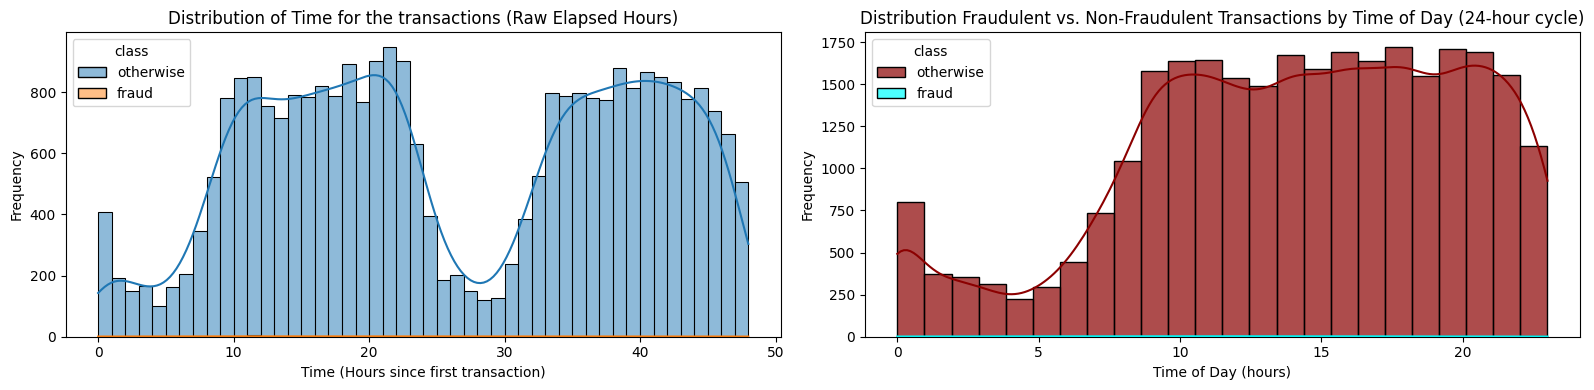

In [12]:
#Reference date is taken as Jan 1 , 2013 suppose , there are 86,400 seconds in a day, and 10 am = 36000 ,  11 pm = 82800.,
# Label the xticks as approx hours of day by dividing the "time" column by 3600 - use floor function
df['time_hours'] = df['time'] / 3600

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4)) # Adjust figsize for two plots side by side

# First plot on ax1: Distribution of raw time (elapsed seconds)
sns.histplot(data=df, bins =48, color ='pink', hue='class', kde=True, x='time_hours', alpha=.5, ax=ax1)
ax1.set_title('Distribution of Time for the transactions (Raw Elapsed Hours)')
ax1.set_xlabel('Time (Hours since first transaction)')
ax1.set_ylabel('Frequency')

# Calculate time_hours for 24-hour cycle for the second plot
df['time_hours'] = df['time'] / 3600
df['time_hours'] = df['time_hours'].apply(lambda x  : int(x)%24)

# Second plot on ax2: Distribution of 24-hour cycle time
custom_palette = {'otherwise': 'darkred', 'fraud': 'cyan'}
sns.histplot(data=df, bins=24, hue='class', x='time_hours', alpha=0.7, palette=custom_palette,
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax2
            )
ax2.set_title('Distribution Fraudulent vs. Non-Fraudulent Transactions by Time of Day (24-hour cycle)')
ax2.set_xlabel('Time of Day (hours)') # Changed label for clarity
ax2.set_ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

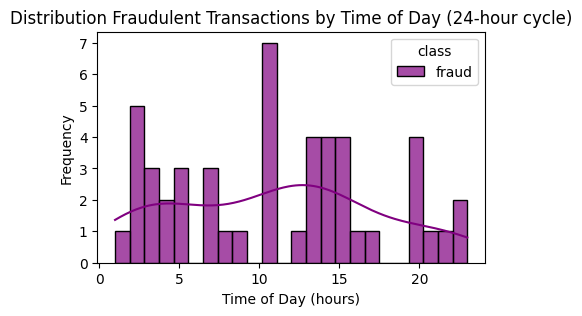

In [13]:
# Plot distribution of only fraud instances by time_hours
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=df[df['class'] == 'fraud'], bins=24, hue='class', x='time_hours', alpha=0.7,
             palette={'otherwise': 'darkred', 'fraud': 'purple'},
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax
            )
ax.set_title('Distribution Fraudulent Transactions by Time of Day (24-hour cycle)')
ax.set_xlabel('Time of Day (hours)') # Changed label for clarity
ax.set_ylabel('Frequency')
plt.show()

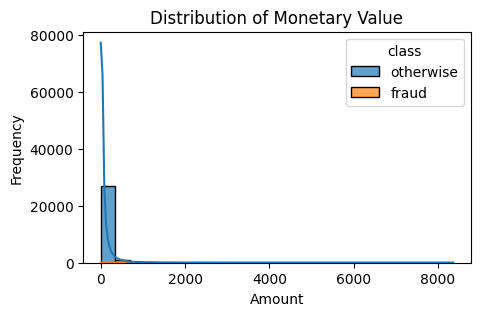

In [14]:
# Plot distribution of transaction amounts
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(data=df, bins=24, hue='class', x='amount', alpha=0.7,
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax
            )
ax.set_title('Distribution of Monetary Value')
ax.set_xlabel('Amount') # Changed label for clarity
ax.set_ylabel('Frequency')
plt.show()

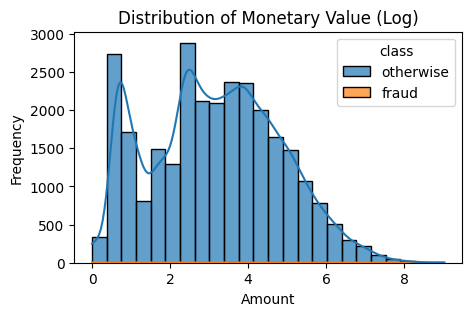

In [15]:
#  Do a log transform and create a new column log_amount
df['log_amount'] = np.log(df['amount'] + 1)
# Plot the same now
fig, ax = plt.subplots(figsize=(5,3))
sns.histplot(data=df, bins=24, hue='class', x='log_amount', alpha=0.7,
             linewidth=1, # Add linewidth for prominence
             kde=True, # Add KDE to show density more clearly
             ax=ax)
ax.set_title('Distribution of Monetary Value (Log)')
ax.set_xlabel('Amount') # Changed label for clarity
ax.set_ylabel('Frequency')
plt.show()

### **Feature Engineering**

Creating high-quality features can significantly improve the model's performance.

No categoral features due to PCA transformation.

For numerical features, transformation is not mandatory, but it is recommended. Normalizing or standardizing numerical features can improve the model's accuracy and stability, especially when variables have very different magnitudes of values. We will use StandardScaler

Handling missing values: Fortunately, no missing values found , 10 duplicates wer removed though.

**Feature selection**: As we saw that having raw values of time is not so useful but to engineer a new time column representing the hour is more useful, hence we would drop the 'time' column but retain the newly created column called

**"time_hours"** because as per the plots above, clearly the transactions have direct relation with the day times vs night times and so are the fraud instances are temporal in nature to some extent.

**Transaction Amount** We also saw that vast majority of transactions are lower in amounts with only a handful towards maximum causing left skewness, prompting us to engineer a new feature called "log_amount"



In [16]:
X= df.drop(columns = ['class','class_bool','time','amount'])
y= df['class_bool']

In [17]:
df.columns

Index(['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10',
       'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20',
       'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount',
       'class', 'class_bool', 'time_hours', 'log_amount'],
      dtype='object')

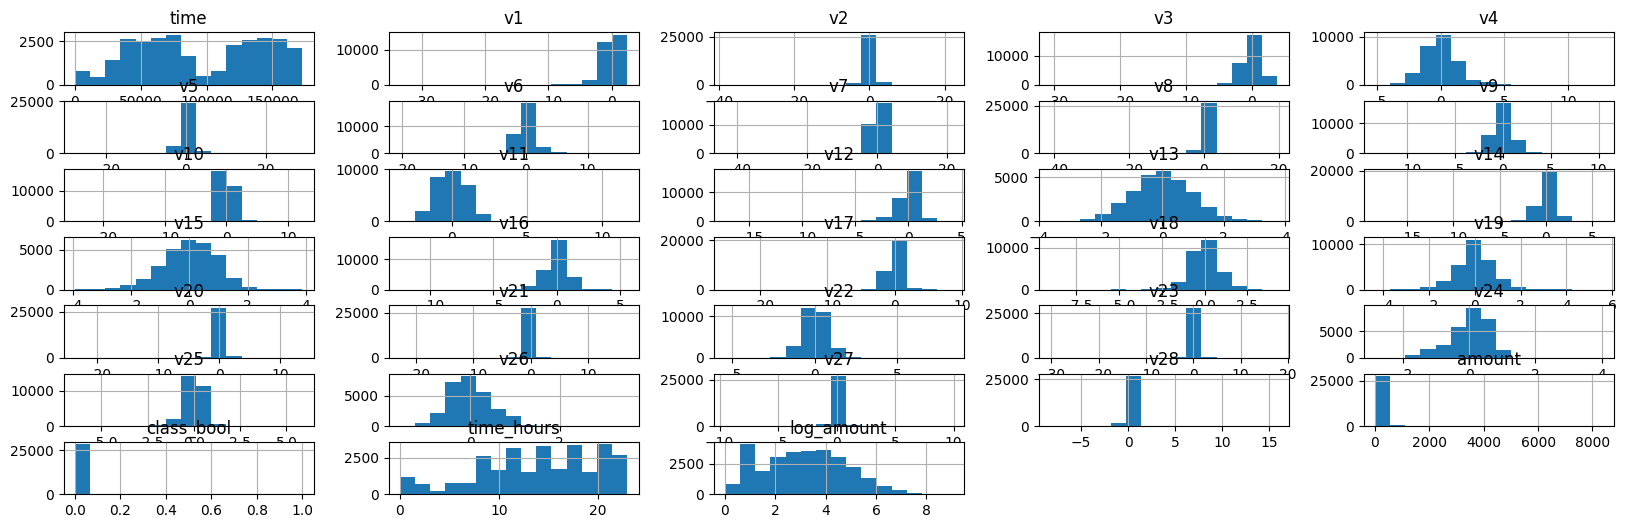

In [18]:
df.hist(bins=15, figsize=(20, 6), layout=(7, 5))
plt.show()

After this analysis, we plot a heatmap to get a coloured
representation of the data and to study the correlation between
out predicting variables and the class variable. This heatmap is
shown below:

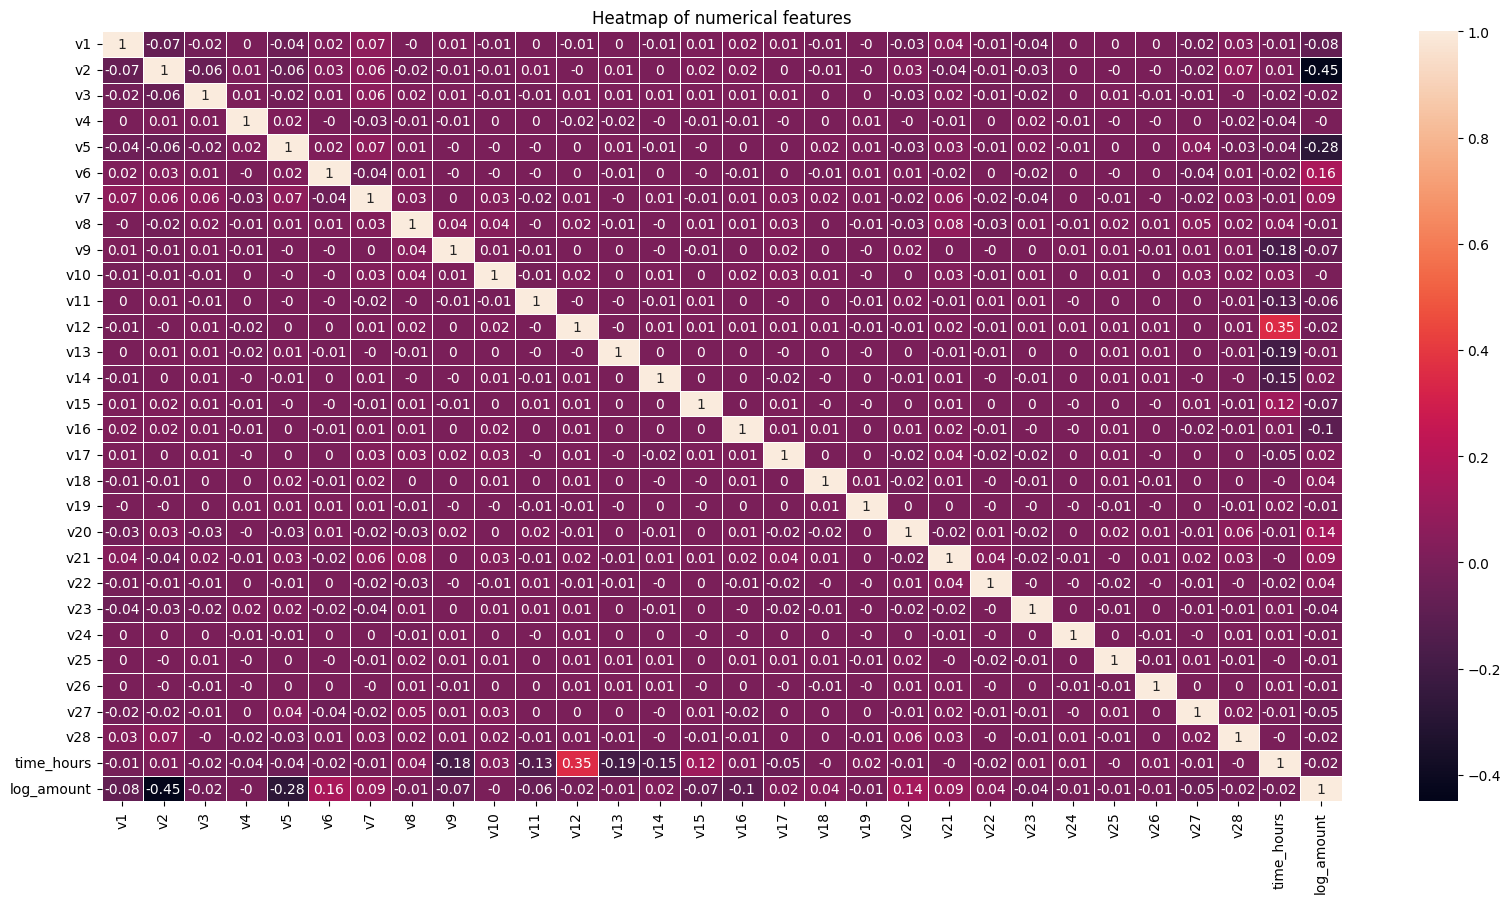

In [19]:
# Plot heatmap of numerical columns to see if there is some multicollinearity
# 1. Select only numerical features

numeric_df = X.select_dtypes(include=['number'])
# 2. Compute the correlation matrix
corr_matrix = numeric_df.corr()
plt.figure(figsize=(20, 10))
#2. Round off to 2 dps only
sns.heatmap(corr_matrix.round(2), annot=True, linewidths=0.5)
plt.title("Heatmap of numerical features")
plt.show()
# No multicollinearity which is good sign for regression models like LogisticRegression, for better model stability.

### Test for multicollinearity
Goes with the general understanding of PCA that removes multicollinearity , very less correlation found among features

The 2 highest absolute values in correlation are with (time_hours,V12) and(log_amount,V2,V5,V6) again reinforcing our understanding of the significance of these 2 features in predictions


### Visualize distribution of selected PCA components vs. target class

While interpreting individual PCA components can be challenging, visualizing their distributions across the target classes can reveal patterns. We'll focus on a few V-columns that showed some correlation with `time_hours` or `log_amount` (e.g., V2, V5, V6, V12) to see if they differentiate between fraud and non-fraud transactions.

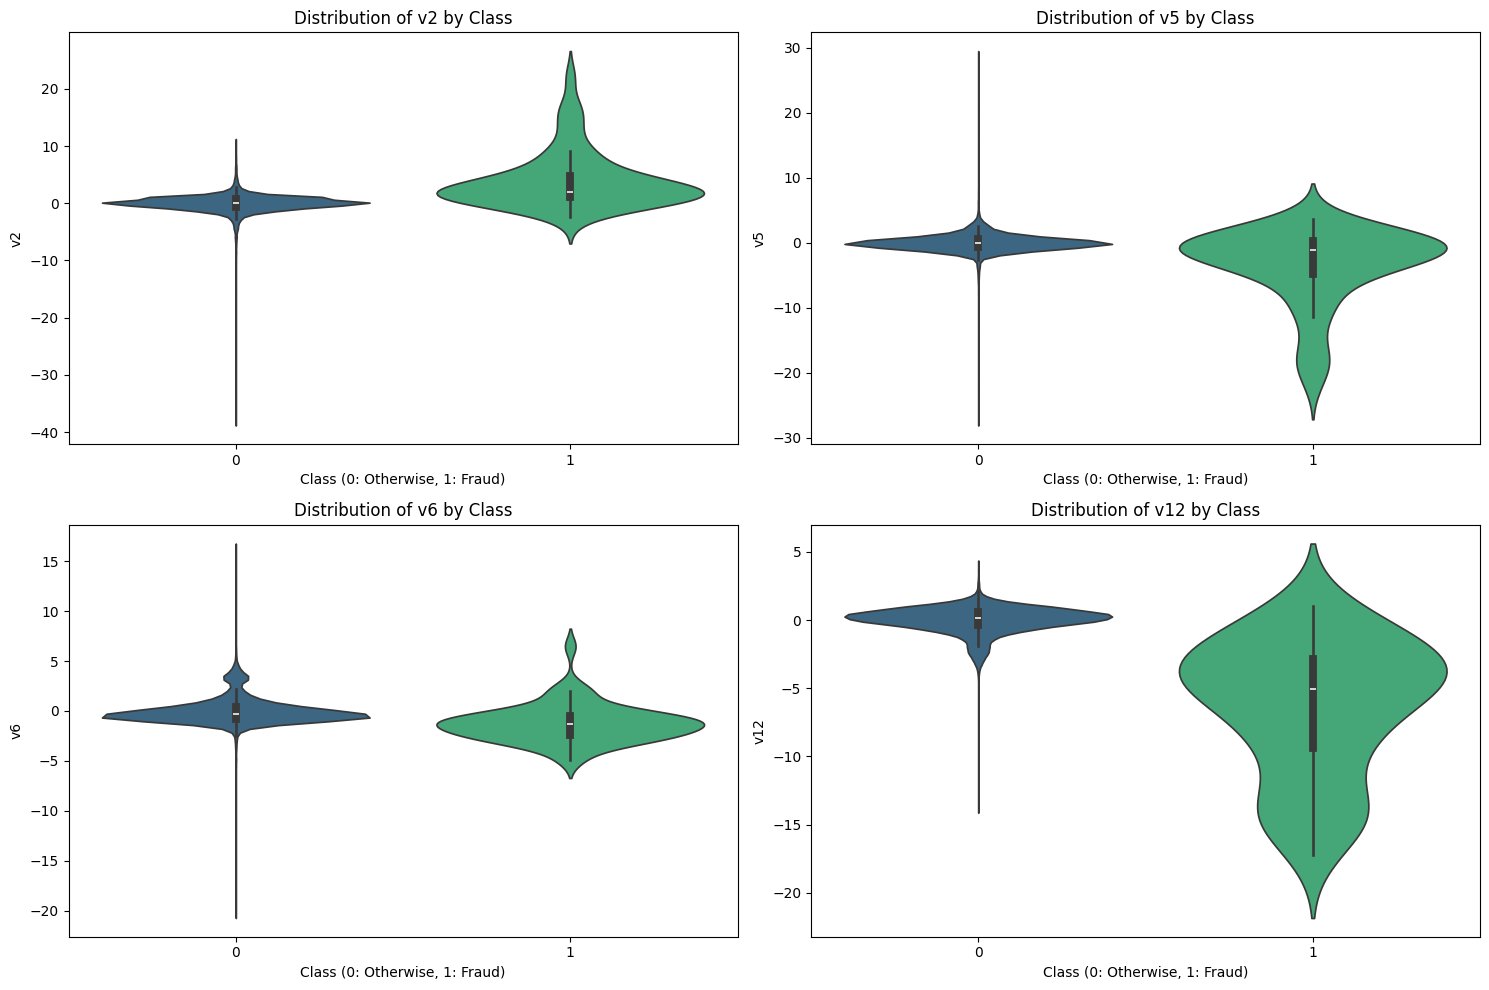

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few V-columns to plot based on previous correlation observations
selected_v_columns = ['v2', 'v5', 'v6', 'v12']

# Combine X and y for plotting convenience
plot_df = pd.concat([X[selected_v_columns], y], axis=1)

# Create subplots for each selected V-column
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(selected_v_columns):
    # Using violin plot instead of box plot for better distribution visualization
    sns.violinplot(x='class_bool', y=col, data=plot_df, ax=axes[i], palette='viridis', hue='class_bool', legend=False)
    axes[i].set_title(f'Distribution of {col} by Class')
    axes[i].set_xlabel('Class (0: Otherwise, 1: Fraud)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Descriptive Statistics for Selected V-Columns by Class

To see the precise median, IQR, min, and max values for each of these features per class, we can compute and display the descriptive statistics.

In [21]:
print('Descriptive Statistics for selected V-columns by Class:')
for col in selected_v_columns:
    print(f'\n--- {col} ---\n')
    display(plot_df.groupby('class_bool')[col].describe())


Descriptive Statistics for selected V-columns by Class:

--- v2 ---



,count,mean,std,min,25%,50%,75%,max
class_bool,,,,,,,,
0,28421.0,0.000798,1.585305,-38.436817,-0.607513,0.069178,0.805366,10.822813
1,49.0,4.019177,4.948639,-2.484824,1.156431,1.927650,4.700055,22.057729



--- v5 ---



,count,mean,std,min,25%,50%,75%,max
class_bool,,,,,,,,
0,28421.0,0.017473,1.333286,-27.737487,-0.686984,-0.049665,0.625956,29.162172
1,49.0,-3.531528,5.951333,-21.665654,-4.708241,-1.162102,0.260821,3.669035



--- v6 ---



,count,mean,std,min,25%,50%,75%,max
class_bool,,,,,,,,
0,28421.0,-0.003183,1.314628,-20.367836,-0.763706,-0.269695,0.405285,16.410638
1,49.0,-1.227555,1.918638,-4.940356,-2.386893,-1.281843,-0.535163,6.474115



--- v12 ---



,count,mean,std,min,25%,50%,75%,max
class_bool,,,,,,,,
0,28421.0,0.020961,0.939834,-13.884393,-0.395006,0.151273,0.621618,4.122374
1,49.0,-6.469354,5.021015,-17.228662,-9.407061,-5.030465,-2.844449,0.999716


In [21]:
# Scatter plots for class sepration in 2D - asuming that PC1, PC2 etc are ordered as v1,v2 etc in terms of retaining the maximum variance.

Text(0.5, 1.0, 'PCA Components: Class Separability')

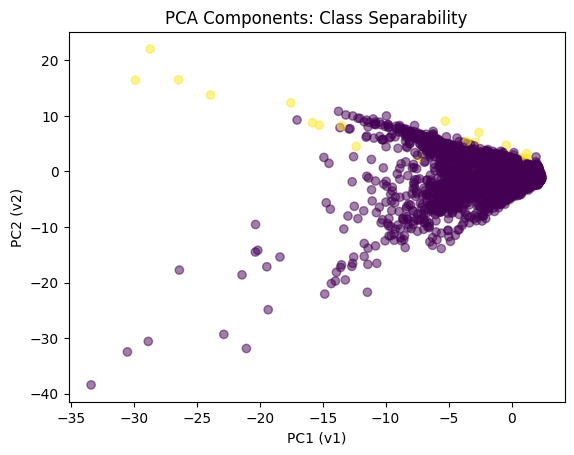

In [87]:
plt.scatter(df['v1'], df['v2'], c=df['class_bool'], alpha=0.5)
plt.xlabel("PC1 (v1)")
plt.ylabel("PC2 (v2)")
plt.title("PCA Components: Class Separability")

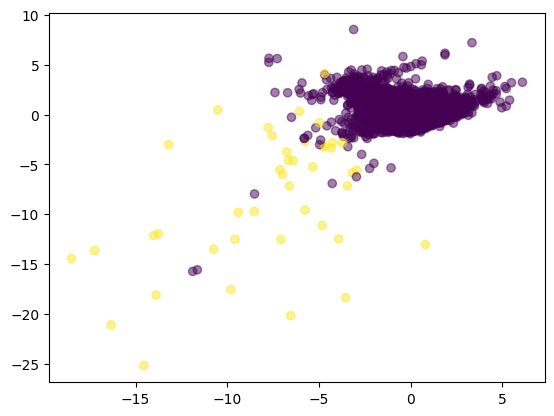

In [90]:
plt.scatter(df['v14'], df['v17'], c=df['class_bool'], alpha=0.5)

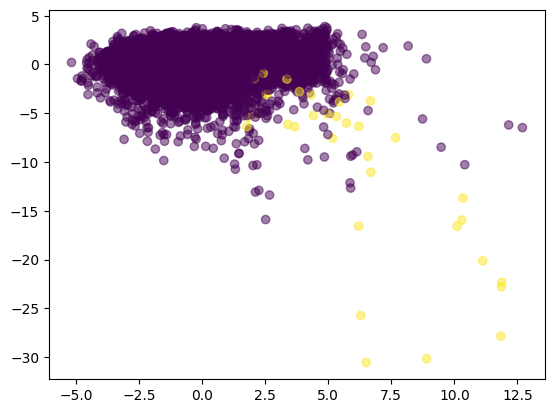

In [91]:
plt.scatter(df['v4'], df['v3'], c=df['class_bool'], alpha=0.5)

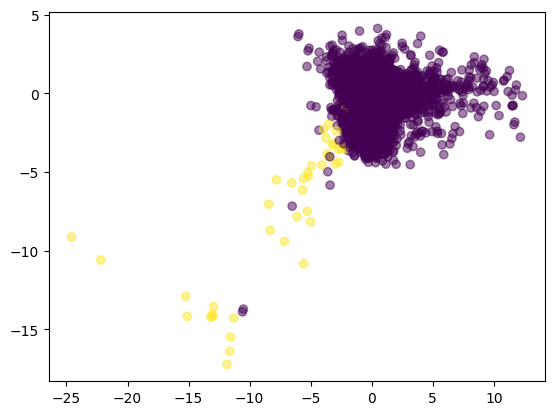

In [92]:
plt.scatter(df['v10'], df['v12'], c=df['class_bool'], alpha=0.5)

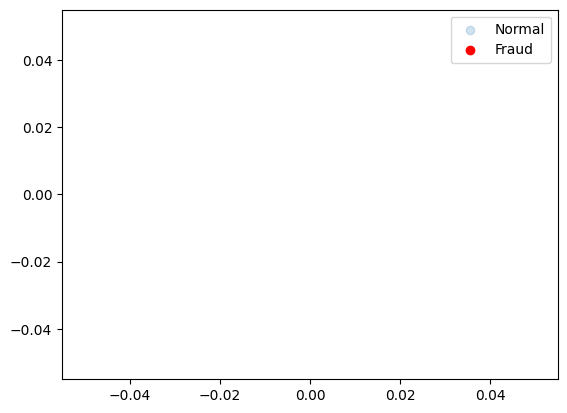

In [96]:
fraud = df[df['class'] == 1]
normal = df[df['class'] == 0]

plt.scatter(normal['v1'], normal['v2'], alpha=0.2, label='Normal')
plt.scatter(fraud['v1'], fraud['v2'], color='red', label='Fraud')
plt.legend()

Text(0.5, 1.0, 'Amount vs. V1')

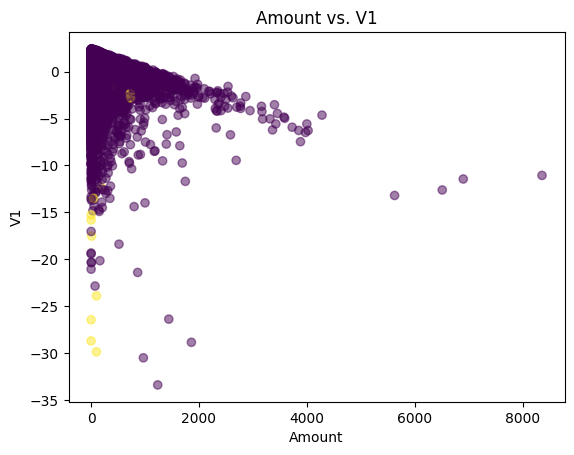

In [100]:
plt.scatter(df['amount'], df['v1'], c=df['class_bool'], alpha=0.5)
plt.xlabel("Amount")
plt.ylabel("V1")
plt.title("Amount vs. V1")

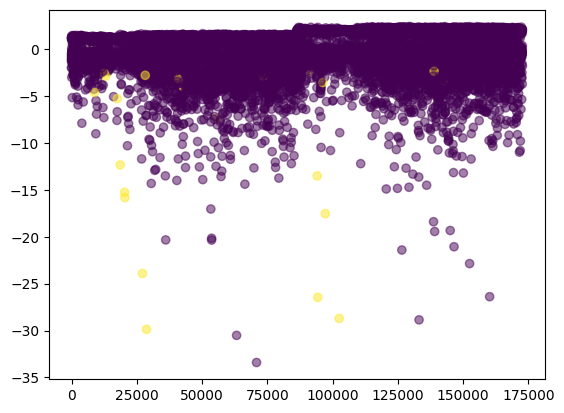

In [102]:
plt.scatter(df['time'], df['v1'], c=df['class_bool'], alpha=0.5)

###**Train Test split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)# Print the sizes
# check if stratify got the desired results
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

class_bool
0    0.998288
1    0.001712
Name: proportion, dtype: float64
class_bool
0    0.998244
1    0.001756
Name: proportion, dtype: float64


In [23]:
y_train.value_counts()

,count
class_bool,
0,22737
1,39


### Data preprocessing

In [24]:
# 1. Define transformers for different column types - we will keep imputers as it is harmless and possibility of unavailable values for future, as a good practice.
# Scale the data for time and amount as they have great variations hence model should not be confused.
num_columns = X.select_dtypes(include=['int64', 'float64']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())#('scaler', MinMaxScaler()) avoiding MM scaler due to big variations in time column .
])

# 2. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_transformer', numeric_transformer,num_columns)
    ]
)

**Synthetic Minority Oversampling (SMOTE)**

Due to extreme class imbalance, SMOTE would be used to augment synthetic fraud cases for the model to have a more balanced split of 2 classes (fraud vs non-fraud) only on the training data to avoid data leakage via pipeline.

Since synthesized data can introduce noise and this is a classification problem, some algorithms may even perform poorly with sampling , hence for each of the listed models above , we would run with and w/o sampling .

IMP NOTE - When SMOTE is defined as a step in the pipeline , SMOTE step is bypassed during prediction to avoid data leakage

**Show the distribution of class Imbalance before and after SMOTE even though we would use Pipeline later**

This is to demonstrate how SMOTE would be fillers for the models to learn on the traning data by imputing syntehtic samples by amplifying the minority class which is the positive class in the case of fraud detection .

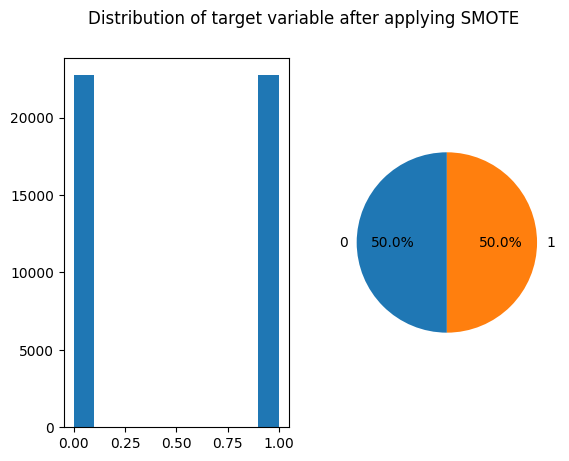

In [25]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
# Plot histogram of target variable y and also the  sliced pie chart and use orange color
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable after applying SMOTE')
ax1.hist(y_resampled)
# use orange color for pie
ax2.pie(y_resampled.value_counts(), labels = y_resampled.unique(), autopct='%1.1f%%',startangle=90)
plt.show()

##A Noskills Model (Dummy classifier)
Before we build our first experimental model even, we want to establish a noskills classifier model .

In [26]:
# Build a dummy classifier
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy="most_frequent")

# Create the final imblearn Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', dummy_clf)
])

# 4. Fit the pipeline
# SMOTE will only be applied during .fit(), not during .predict()
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11',
       'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21',
       'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'time_hours',
       'log_amount'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

Baseline Dummy model (test):
Accuracy: 0.9982437653670531
Precision: 0.0
recall: 0.0
F1: 0.0
Confusion matrix:
 [[5684    0]
 [  10    0]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      5684
           1       0.00      0.00      0.00        10

    accuracy                           1.00      5694
   macro avg       0.50      0.50      0.50      5694
weighted avg       1.00      1.00      1.00      5694

ROC-AUC: 0.5


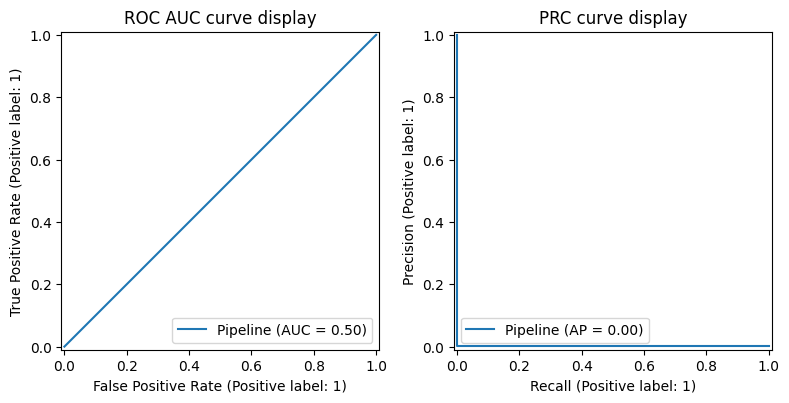

In [27]:
y_dummy_pred = pipeline.predict(X_test)
baseline_proba = pipeline.predict_proba(X_test)[:, 1]
print("Baseline Dummy model (test):")
print("Accuracy:", accuracy_score(y_test, y_dummy_pred))

#Ignore division by 0- add to all of the scores formulae
print("Precision:", precision_score(y_test, y_dummy_pred, zero_division=0))
print("recall:", recall_score(y_test, y_dummy_pred , zero_division=0))
print("F1:", f1_score(y_test, y_dummy_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_dummy_pred))
print("Classification report:\n", classification_report(y_test, y_dummy_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display")
PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display")
plt.tight_layout()
plt.show()

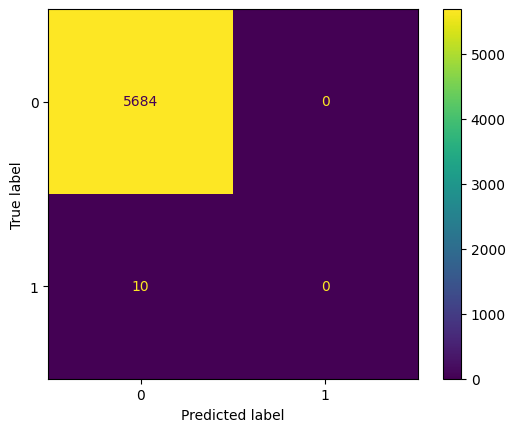

In [28]:
ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()

###**Supervised algorithms**
**Logistic Regression**

In [29]:
lr_model = LogisticRegression(random_state=42, max_iter=10000)
# Create the final imblearn Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', lr_model)
])

print(f"Fitting LR model...at ", datetime.now(), " UTC")
start_time = timer()
lr_pipeline.fit(X_train, y_train)
lr_y_preds=lr_pipeline.predict(X_test)
train_time_model = timer() - start_time

# Print number of iterations using model.n_iter_ and time taken to train
print("Training time:", train_time_model)
print("Number of iterations:", lr_pipeline.named_steps['classifier'].n_iter_)

Fitting LR model...at  2026-04-29 20:38:29.552747  UTC
Training time: 0.49118101800002023
Number of iterations: [37]


Logistic Regression model (train):
Accuracy: 0.9816912539515279
Precision: 0.08370044052863436
recall: 0.9743589743589743
F1: 0.15415821501014199
Confusion matrix:
 [[22321   416]
 [    1    38]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     22737
           1       0.08      0.97      0.15        39

    accuracy                           0.98     22776
   macro avg       0.54      0.98      0.57     22776
weighted avg       1.00      0.98      0.99     22776

ROC-AUC: 0.9980343797470067


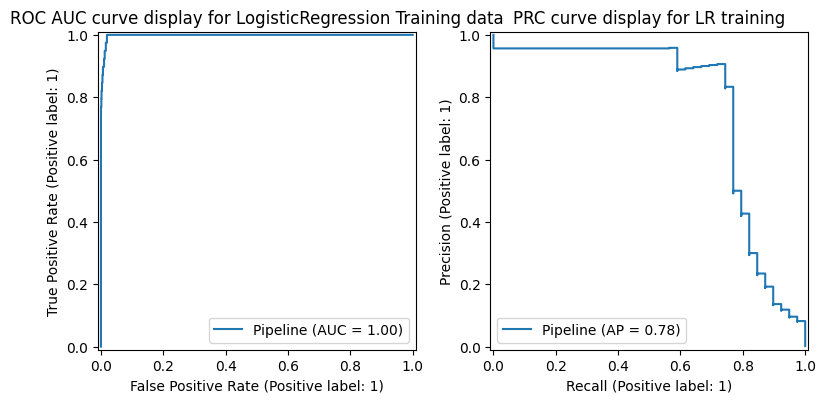

In [30]:
# PLot the accuracy , confusion matrix and the ROC plots including precision recall curve , very important for balanced train dataset
lr_proba = lr_pipeline.predict_proba(X_train)[:, 1]
lr_y_train_preds=lr_pipeline.predict(X_train)
print("Logistic Regression model (train):")
print("Accuracy:", accuracy_score(y_train, lr_y_train_preds))

print("Precision:", precision_score(y_train, lr_y_train_preds))
print("recall:", recall_score(y_train, lr_y_train_preds))
print("F1:", f1_score(y_train, lr_y_train_preds, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_train, lr_y_train_preds))
print("Classification report:\n", classification_report(y_train, lr_y_train_preds))
print("ROC-AUC:", roc_auc_score(y_train, lr_proba))

#Create subplots  for training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(lr_pipeline, X_train, y_train, ax = ax1)
ax1.set_title("ROC AUC curve display for LogisticRegression Training data")
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_train, y_train, ax =ax2)
ax2.set_title("PRC curve display for LR training")
plt.tight_layout()
plt.show()

Logistic Regression model (test):
Accuracy: 0.9813839128907622
Precision: 0.08620689655172414
recall: 1.0
F1: 0.15873015873015872
Confusion matrix:
 [[5578  106]
 [   0   10]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      5684
           1       0.09      1.00      0.16        10

    accuracy                           0.98      5694
   macro avg       0.54      0.99      0.57      5694
weighted avg       1.00      0.98      0.99      5694

ROC-AUC: 0.9997185080928924


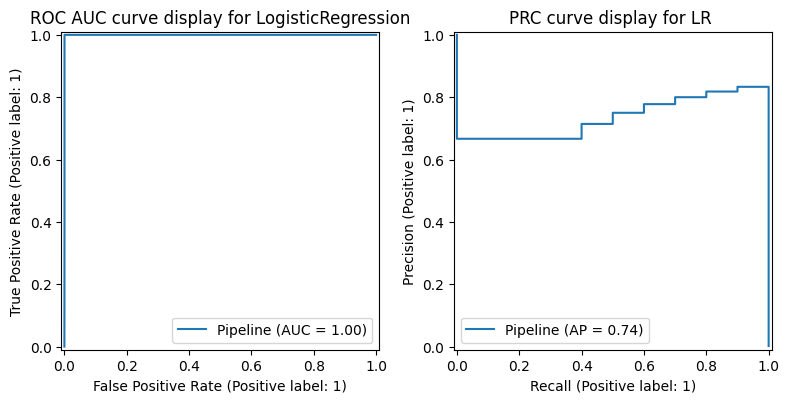

In [31]:
# PLot the accuracy , confusion matrix and the ROC plots including precision recall curve , very important for imbalanced datasets
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression model (test):")
print("Accuracy:", accuracy_score(y_test, lr_y_preds))

print("Precision:", precision_score(y_test, lr_y_preds))
print("recall:", recall_score(y_test, lr_y_preds))
print("F1:", f1_score(y_test, lr_y_preds, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_y_preds))
print("Classification report:\n", classification_report(y_test, lr_y_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display for LogisticRegression")
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display for LR ")
plt.tight_layout()
plt.show()

#Prepare a table for the above metrics for later usage.

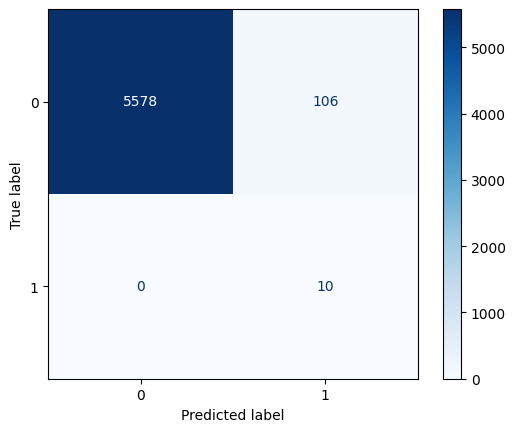

In [32]:
ConfusionMatrixDisplay.from_estimator(lr_pipeline, X_test, y_test, cmap='Blues')
plt.show()
# Can see that almost 100 FPs are generated, which is not great.

### Metrics and their interpretation

- **True Positive (TP)**: Occurs when the model predicts that transaction is a fraud  (prediction = 1), and that is actually a fraud (actual value = 1).
- **True Negative (TN)**: Occurs when the model predicts that transaction is not a fraud (class='otherwise') (prediction = 0), and that transaction is actually not a fraud (actual value = 0).
- **False Positive (FP)**: Occurs when the model predicts the tran being fraud (prediction = 1), but that is wrong meanng it was not a fraud (actual value = 0).
- **False Negative (FN)**: Occurs when the model predicts that transaction is not a fraud (prediction = 0), but it is fraud (actual value = 1).

**IMPORTANT** This metric FN is the most important among above for the model because even a single missed detection can cause unimaginable losses. The recall score is representative of detection of actual fraud cases which we would evaluate later .


**Performance metric to be relied on for this dataset for this classification problem**

 Area Under the Precision-Recall Curve (AUPRC) metric, with a focus on recall since we aim to detect as many fraud cases as possible.

 We see that the model performs similarly on training and test dataset.

 PRC AUC (Precision-Recall Curve - Area Under the Curve): This metric plots Precision against Recall at various threshold settings. Precision measures the proportion of true positive predictions among all positive predictions, while Recall measures the proportion of true positive predictions among all actual positive instances. The PRC is much more sensitive to the performance on the minority class. A low PRC AUC, even with a high ROC AUC, suggests that while your model might be good at identifying most of the positive cases (high recall), it also produces a significant number of false positives (low precision) when trying to achieve that high recall. This is often the case when the number of actual positive samples is very small.


F1-score explanation - This is the harmonic mean between precision and recall and keeps a balance between P and R , poor score of 0.16 on unseen data reinforces the idea that the model is not too great.


### **Interpretation of the above results**

98% accuracy and ROC AUC of 1.0 are due to extreme class imbalance. While this is better than the noskills classifier alwasys predicting majority class, the AUPRC score of 0.75 is not great considering the whole point of fraud detection is to achieve close to 100% recall to avoid a single false negative considerting the massive negative impact.

Noise Amplification: Most likely what happened is given that fraudulent data point is an outlier—an isolated transaction that doesn't share characteristics with other fraud, SMOTE created synthetic data points around this noise, leading to higher False Positives and an unclear decision boundary.

In summary, for imbalanced datasets like fraud detection, PRC AUC is generally a more reliable and informative metric than ROC AUC because it focuses on the performance of the minority class, which is typically the class of interest. PRC AUC of 0.75 suggests .


The difference in your ROC AUC (1.0) and PRC AUC (0.67) with 98% accuracy for an imbalanced dataset like fraud detection is actually expected and highlights why choosing the right metric is crucial for such problems. Here's a breakdown:

ROC AUC (Receiver Operating Characteristic - Area Under the Curve): This metric plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings. An ROC AUC of 1.0 indicates a perfect classifier, meaning it can distinguish between positive and negative classes perfectly without any overlap. However, for highly imbalanced datasets, the ROC curve can be misleading because the FPR doesn't effectively penalize misclassifications of the minority class. Even if a model misclassifies all minority class instances, if the number of negative instances is vast, the FPR can still be low, leading to an overly optimistic ROC AUC.



###Do grid search on LogisticRegression
GridSearchCV would be run for identifying correct hyperparameters yielding best estimator results. Training and prediction times would also be kept in mind in deciding an optimal classifier .

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [34]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1,10],  # Regularization strength
        "model__solver": ["liblinear", "lbfgs"]  # Optimization algorithms
    }
   }

In [35]:
# Redefine the models- Keep SVM out for now as it is running for long time and does not complete eventually even with only a few param combinations.
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42)

}
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=2000, random_state=42))])

In [51]:
from datetime import datetime
# Perform cross validation using grid search , use F1 scoring as this is a classfication problem and we intend to find a balance between precision and recall.
# Reason is that we want to detect as many potential customers as possible without missing many, while
# also avoiding reaching out unnecessarily to customers in a directed campaign who are unlikely to opt for subscription.
from timeit import default_timer as timer

best_models = {}
results_cv = []
for name, model in models.items():
    # Include SMOTE in the pipeline for GridSearchCV
    cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=42)), ("model", model)])
    grid = GridSearchCV(cvpipe, param_grid=param_grids[name], scoring="f1", cv=cv, n_jobs=-1)## choose F1 as score .
    start_time = timer()
    print(f"Tuning {name}...at ", datetime.now(),  " UTC")
    grid.fit(X_train, y_train)
    train_time_model = timer() - start_time
    best_models[name] = grid.best_estimator_

    # Compute performance metrics on train and test sets
    # Predict classes
    y_tr_pred = grid.best_estimator_.predict(X_train)
    y_te_pred = grid.best_estimator_.predict(X_test)

    # Store results
    results_cv.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_, "Train Time": train_time_model,
        'Train Accuracy': accuracy_score(y_train, y_tr_pred),
        'Train F1': f1_score(y_train, y_tr_pred),
        'Train Recall': recall_score(y_train, y_tr_pred),
        'Train Precision': precision_score(y_train, y_tr_pred),

        'Test Accuracy': accuracy_score(y_test, y_te_pred),
        'Test F1': f1_score(y_test, y_te_pred),
        'Test Recall': recall_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred)
    })

results_cv_df = pd.DataFrame(results_cv).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)

Tuning Logistic Regression...at  2026-04-29 22:51:15.205903  UTC


In [52]:
results_cv_df.sort_values(by="best_f1_cv", ascending=False, inplace=True)
results_cv_df

,model,best_f1_cv,best_params,Train Time,Train Accuracy,Train F1,Train Recall,Train Precision,Test Accuracy,Test F1,Test Recall,Test Precision
0,Tuned Logistic Regression,0.189738,"{'model__C': 10, 'model__solver': 'lbfgs'}",29.87965,0.981735,0.154472,0.974359,0.083885,0.981735,0.16129,1.0,0.087719


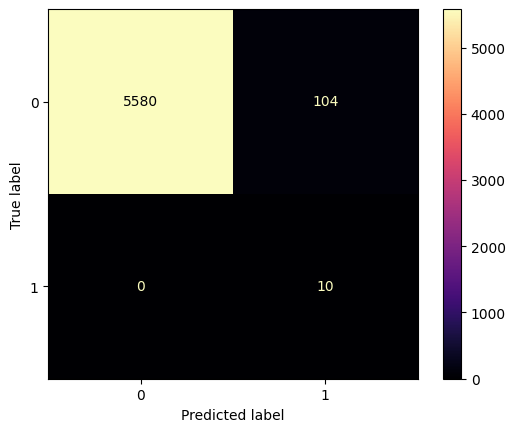

In [38]:
ConfusionMatrixDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, cmap='magma')
plt.show()

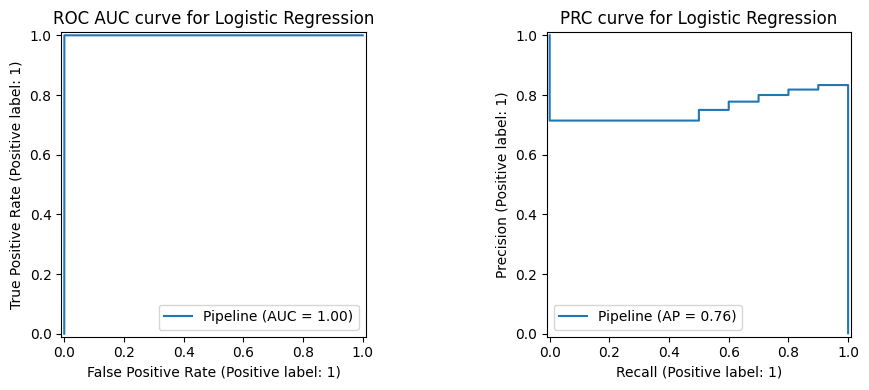

In [53]:
#Display the AUPRC and ROC for the best estimator in subplots Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) # Reduced figsize for side-by-side plots
RocCurveDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax1)
ax1.set_title("ROC AUC curve for Logistic Regression")
PrecisionRecallDisplay.from_estimator(best_models["Logistic Regression"], X_test, y_test, ax=ax2)
ax2.set_title("PRC curve for Logistic Regression")
plt.tight_layout()
plt.show()

### CHECK COLLAB ACTIVITY 13.3 FOR INCREASING / DECREASING HYPERPARAMETER 1/C on Logistic Regression*



In [76]:
Cs = np.linspace(0.00001  ,.5)# different cvalues of regularization parameters,larger the values , smaller amounts of regularazation (c = inverse of lambda) # default 50 samples
coef_list = []
for C in Cs:
  lgr = LogisticRegression(penalty='l1',solver='liblinear',C=C, random_state=42,max_iter=1000)
  lgr.fit(X_train_processed,y_train)
  coef_list.append(lgr.coef_[0])

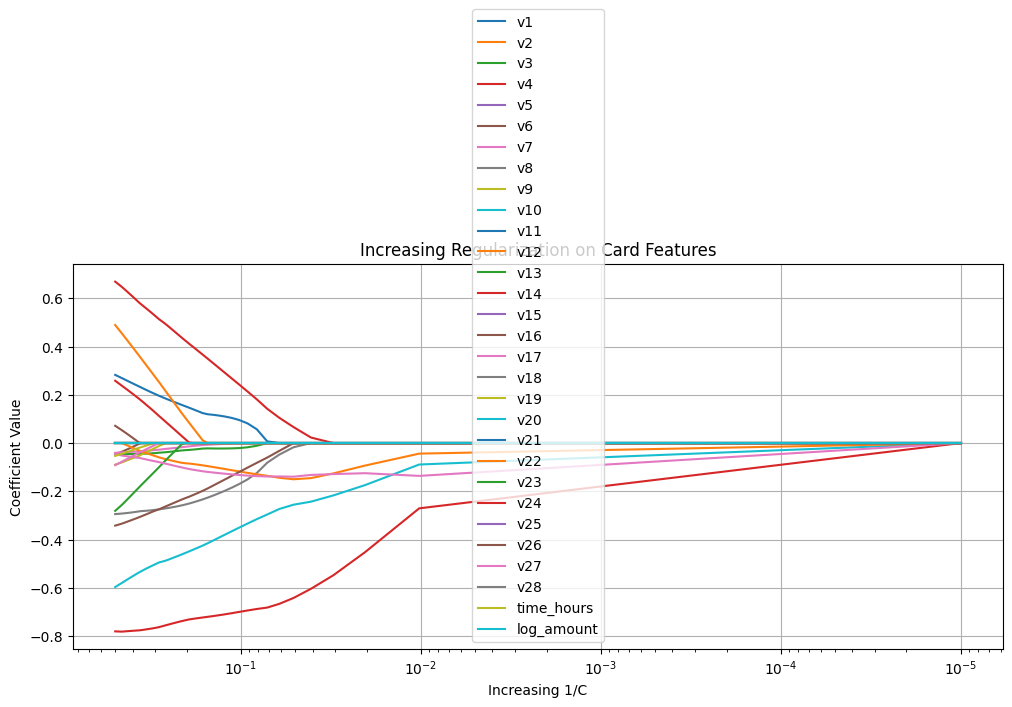

In [82]:
plt.figure(figsize = (12, 5))
plt.semilogx(coef_df)
plt.gca().invert_xaxis()
plt.grid()
plt.legend(list(coef_df.columns));
plt.title('Increasing Regularization on Card Features')
plt.xlabel("Increasing 1/C")
plt.ylabel("Coefficient Value");
# Do note that the C is invwerse of lambda , with increasing 1/C , regularization strength increases, hence shrinking the coefs of the features towards 0 .

In [84]:
from sklearn.feature_selection import SelectFromModel
log_reg = LogisticRegression(C=0.1,random_state=43 ,penalty='l1',solver = 'liblinear')
selector = SelectFromModel(log_reg)
selector.fit_transform(X_train_processed,y_train)

best_features = selector.get_feature_names_out()

### ANSWER CHECK
print(best_features)

['x2' 'x3' 'x7' 'x9' 'x11' 'x13' 'x15' 'x16' 'x20']


### Plot the shap summary for feature interpretability and importance

This plot helps us understand the feature importance and how each feature impacts the model's output.

In [68]:
import shap

# 1. Extract the fitted Logistic Regression model from the best pipeline
fitted_lr_model = best_models["Logistic Regression"].named_steps['model']

# 2. Extract the preprocessor from the best pipeline and transform X_train and X_test using same preprocesor
preprocessor_from_pipeline = best_models["Logistic Regression"].named_steps['preprocess']
X_train_processed = preprocessor_from_pipeline.transform(X_train)
X_test_processed = preprocessor_from_pipeline.transform(X_test)

# Convert processed arrays back to DataFrame for SHAP to retain feature names
num_columns = X.columns # all numerical columns
X_train_processed_df = pd.DataFrame(X_train_processed, columns=num_columns)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=num_columns)

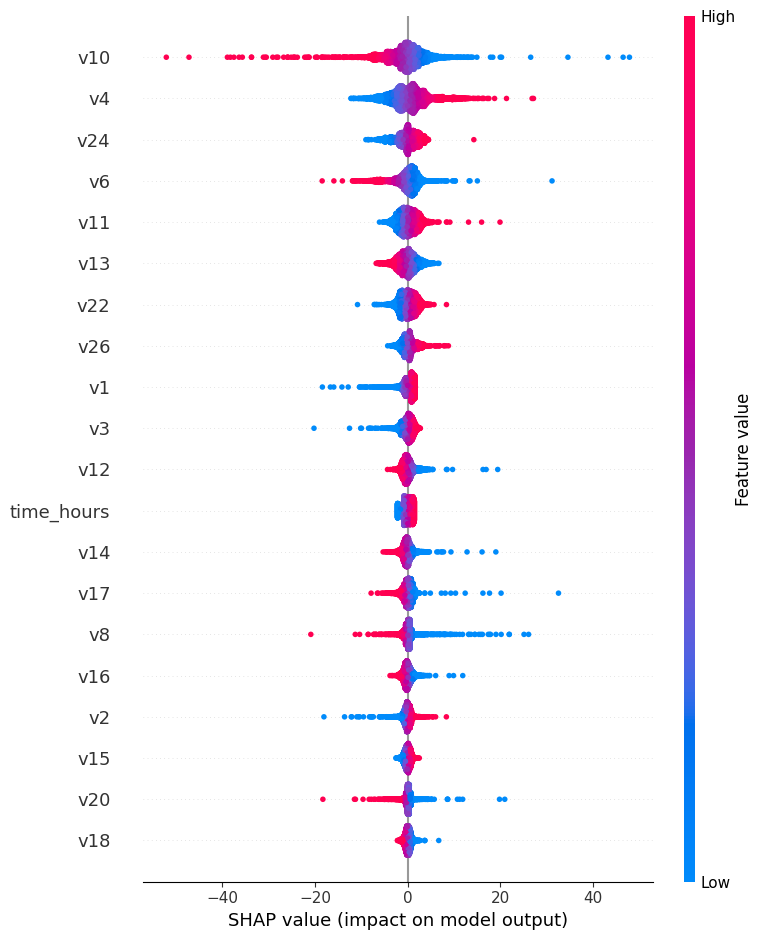

In [69]:
# Use SHAP's LinearExplainer with the fitted model and processed training data
# The `X_train_processed_df` here acts as the background dataset for the explainer
explainer = shap.LinearExplainer(fitted_lr_model, X_train_processed_df)

# Compute SHAP values for the processed test set
shap_values = explainer.shap_values(X_test_processed_df)

# Plot the SHAP summary using the processed test set with feature names
shap.summary_plot(shap_values, X_test_processed_df)

Observations from above SHAP plot -

1.Feature Importance - Plot sorts the features as per their importance in making predictions in descending order. Hence , v10,v4,v24 and v6 are the most significant features in having an impact on model's predictions,  even Though PCA transformations got ordered by V1,V2...  as per retaining the maximum variance in the data.

2.Direction of impact - A positive SHAP value meaning towards right , pushes the predictions towards positive class ie 1 , while a negative value towards non-fraud .

3.For v10 as an example, red is on left , blue is on right, this implies that as the most important predictor for model, high values of this feature would push the transaction to be classified as normal , whereas lower values would tend to classify the transaction as fraud. Similarly, for other features.

This also shows that impact of when a transacton is done has some impact on frauds but not a lot as it is somehwat mid way in terms of importance.

**Important Note** We extracted the preprocessor and the best model estimator from within the pipleline but intentionally did not include the SMOTE step to avoind the feature interpretability from being influenced by synthetic samples.

### **Business Insights on the above experiment with Logistic Regression**

1.

2.**The importance of feature "time"**
We can see that most of the transactions happend during day time and least numbers of transactions hapended during night. This provided great temporal imputs on developing time sensitive models such as LSTM and LSTM attention models to understand which past transactions or events are more usedul in predicting current outcome . We would explore some of these in Future Neural Network based models.

Time-Delta Computation: Models calculate the time gap between consecutive transactions to identify sudden bursts of activity, which are often indicative of fraud in real time systems

The transacations can be further broken down in days_of_week, time_of_day, weekend etc in developing more robust models.

3.  Feature Importance-

4. Interpretability of PCA components-

### **Future work**
After a few weeks , we would explore plenty of other models from the list below for their ability to distinguish classes in dense data along with higher rates of detectability (high recall and F1 score ). Their primary benefits are listed below - in the context of high class imbalanced data.


1.**Random Forest** - Tree ensemble method, by taking average of multiple trees on bootstrapped samples, reduces risk of overfitting typical of decision trees.

2.**Voting Classifier** - I will take an ensemble approach including (LR,Decision tree and SVM)

3.**XGBoost** - Provides massive improvement over Logistic Regression by cobining multiple weak trees and additive improvements. Pertinent for fraud detection as it prioritizes recall and reducing false positives at the same time. This is a scalable solution used in banking industry dealing with streaming and big data.

4.**Autoencoder** - Unsupervised technique trained on normal transactions and abnormalities detected via reconstruction of unseen data with high errrors .  

5.**Isolation Forest**- Unsupervised - Fraud cases can be considered anomoalies in an otherwise normal dataset, by building mutliple trees and isolating outliers.